In [1]:
pip install "numpy<2.0,>=1.24.0"

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'D:\Project\Waste Classification\WasteClassification\imageclassification\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
import tensorflow as tf
print(tf.__version__)

2.10.0


In [3]:
pip install opencv-python matplotlib

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'D:\\Project\\Waste Classification\\WasteClassification\\imageclassification\\Lib\\site-packages\\~3mpy.libs\\libopenblas64__v0.3.23-293-gc2f4bdbb-gcc_10_3_0-2bde3a66a51006b2b53eb373ff767a3f.dll'
Check the permissions.

You should consider upgrading via the 'D:\Project\Waste Classification\WasteClassification\imageclassification\Scripts\python.exe -m pip install --upgrade pip' command.


In [4]:
!pip list

Package                      Version
---------------------------- -----------
absl-py                      2.3.1
asttokens                    3.0.0
astunparse                   1.6.3
blinker                      1.9.0
cachetools                   5.5.2
certifi                      2025.8.3
charset-normalizer           3.4.3
click                        8.2.1
colorama                     0.4.6
comm                         0.2.3
contourpy                    1.3.2
cycler                       0.12.1
debugpy                      1.8.16
decorator                    5.2.1
exceptiongroup               1.3.0
executing                    2.2.0
Flask                        3.1.2
flatbuffers                  25.2.10
fonttools                    4.60.1
gast                         0.4.0
google-auth                  2.40.3
google-auth-oauthlib         0.4.6
google-pasta                 0.2.0
grpcio                       1.74.0
h5py                         3.14.0
idna                         3.10
ip

You should consider upgrading via the 'D:\Project\Waste Classification\WasteClassification\imageclassification\Scripts\python.exe -m pip install --upgrade pip' command.


In [4]:
import tensorflow as tf
import os

In [5]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [6]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [7]:
import tensorflow as tf

# Check available physical devices
gpus = tf.config.list_physical_devices('GPU')
print("GPUs detected:", gpus)

# Quick test
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU Available (legacy check):", tf.test.is_gpu_available(cuda_only=False, min_cuda_compute_capability=None))


GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs Available: 1
Built with CUDA: True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU Available (legacy check): True


In [8]:
from tensorflow.python.client import device_lib

# List all local devices
devices = device_lib.list_local_devices()
for d in devices:
    if d.device_type == 'GPU':
        print(d.physical_device_desc)


device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [9]:
import cv2
import imghdr

In [10]:
data_dir = 'data1' 

In [11]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [12]:
for image_class in os.listdir(data_dir): 
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try: 
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts: 
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e: 
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

In [13]:
import numpy as np
from matplotlib import pyplot as plt

In [14]:
data = tf.keras.utils.image_dataset_from_directory('data1')

Found 15515 files belonging to 12 classes.


In [15]:
data

<BatchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [16]:
data_iterator = data.as_numpy_iterator()

In [17]:
batch = data_iterator.next()

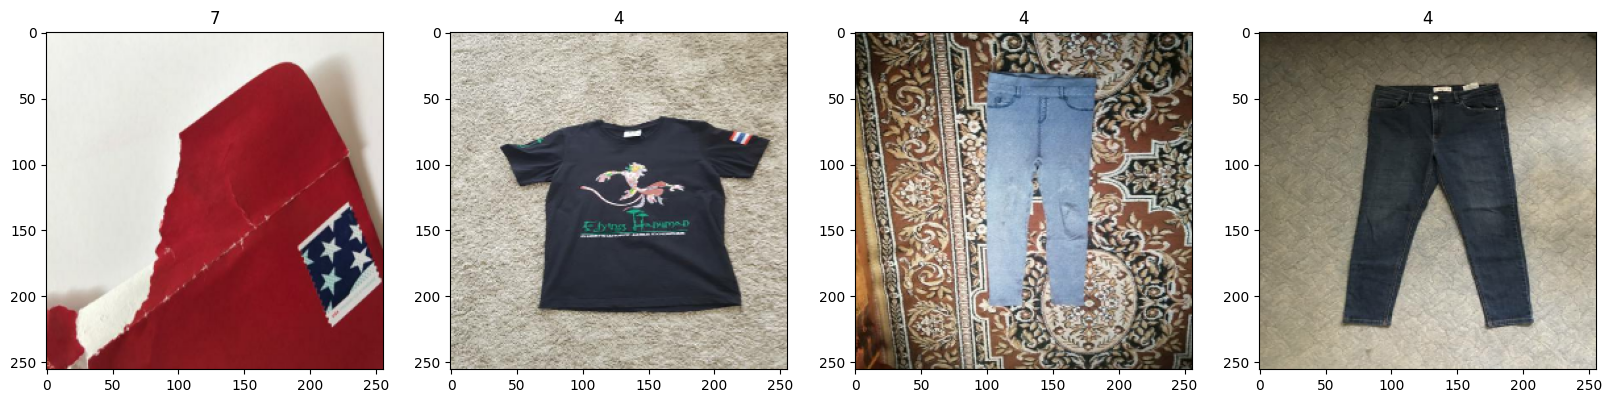

In [18]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [19]:
data = data.map(lambda x,y: (x/255, y))

In [20]:
scaled_iterator = data.as_numpy_iterator()

In [21]:
batch = scaled_iterator.next()

In [22]:
batch[0].min()

0.0

In [23]:
batch[0].max()

1.0

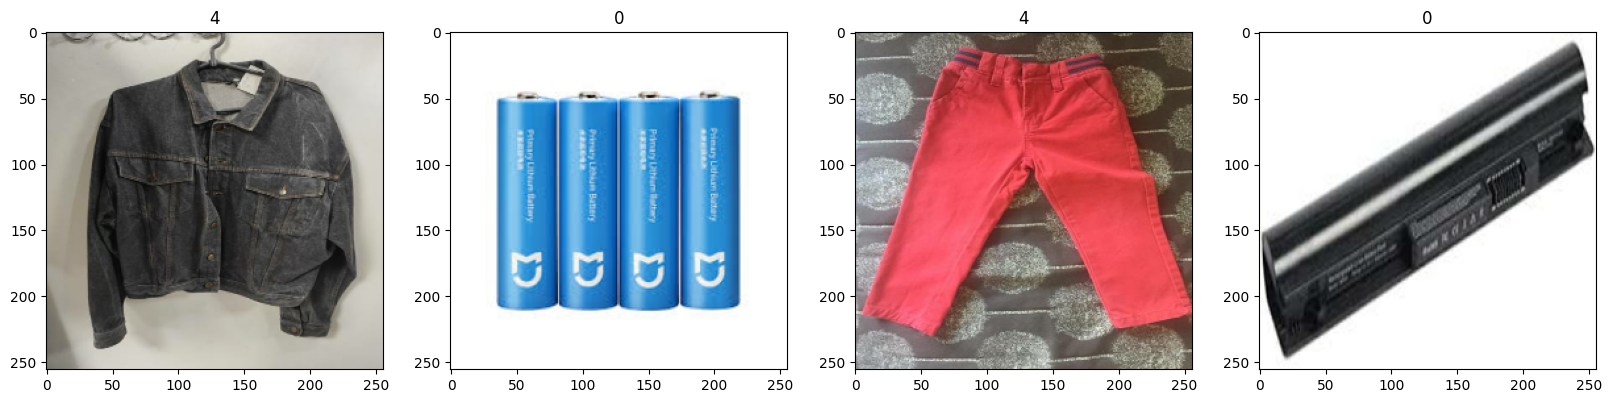

In [24]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

In [25]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [26]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization

In [28]:
model = Sequential()

In [29]:
num_classes = 12

In [30]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Load VGG16 as base model (without top layers)
base_model = VGG16(include_top=False, input_shape=(256, 256, 3), weights="imagenet")
base_model.trainable = False  # freeze base model (use pretrained features)

# Build new model on top
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # multi-class
])

# Compile
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 8, 8, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 32768)             0         
                                                                 
 dense (Dense)               (None, 512)               16777728  
                                                                 
 batch_normalization (BatchN  (None, 512)              2048      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 12)                6156      
                                                      

In [31]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping and save best model
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    train,  # your training dataset
    validation_data=val,  # your validation dataset
    epochs=50,
    callbacks=callbacks
)


Epoch 1/50
339/339 [==============================] - 148s 368ms/step - loss: 0.7690 - accuracy: 0.7684 - val_loss: 0.4203 - val_accuracy: 0.8689
Epoch 2/50
339/339 [==============================] - 126s 370ms/step - loss: 0.2957 - accuracy: 0.9054 - val_loss: 0.3602 - val_accuracy: 0.8879
Epoch 3/50
339/339 [==============================] - 158s 465ms/step - loss: 0.1775 - accuracy: 0.9523 - val_loss: 0.3442 - val_accuracy: 0.8947
Epoch 4/50
339/339 [==============================] - 218s 641ms/step - loss: 0.1199 - accuracy: 0.9705 - val_loss: 0.3772 - val_accuracy: 0.8818
Epoch 5/50
339/339 [==============================] - 128s 376ms/step - loss: 0.0913 - accuracy: 0.9791 - val_loss: 0.3340 - val_accuracy: 0.8969
Epoch 6/50
339/339 [==============================] - 127s 373ms/step - loss: 0.0714 - accuracy: 0.9841 - val_loss: 0.3572 - val_accuracy: 0.8924
Epoch 7/50
339/339 [==============================] - 125s 366ms/step - loss: 0.0613 - accuracy: 0.9873 - val_loss: 0.3706 -

In [32]:
# Unfreeze last 4 layers of VGG16
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Re-compile with smaller learning rate
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',  # multi-class
              metrics=['accuracy'])


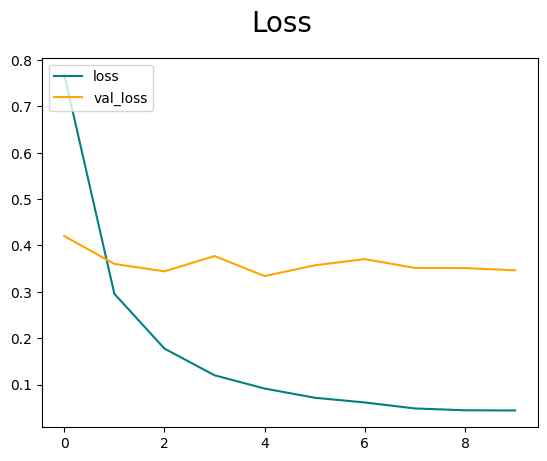

In [33]:
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

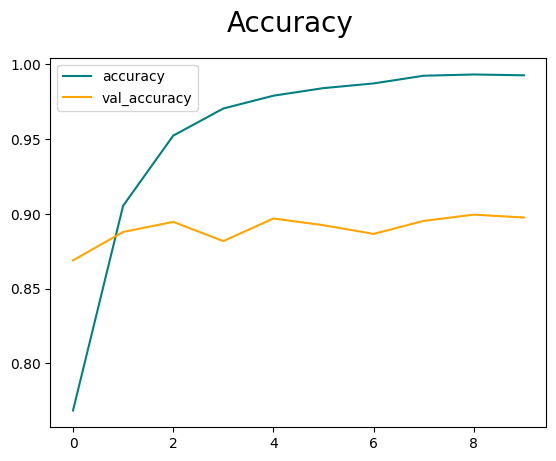

In [34]:
fig = plt.figure()
plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [35]:
!pip install scikit-learn

You should consider upgrading via the 'D:\Project\Waste Classification\WasteClassification\imageclassification\Scripts\python.exe -m pip install --upgrade pip' command.


In [36]:
!pip install seaborn

You should consider upgrading via the 'D:\Project\Waste Classification\WasteClassification\imageclassification\Scripts\python.exe -m pip install --upgrade pip' command.


1/1 [==============================] - 0s 93ms/step
              precision    recall  f1-score   support

   cardboard       0.86      0.90      0.88        96
     clothes       0.93      0.92      0.92       109
       glass       0.88      0.70      0.78        63
 green-glass       0.87      0.80      0.84        95
       metal       0.97      0.98      0.98       500
       paper       0.91      0.87      0.89        70
     plastic       0.76      0.76      0.76        94
       shoes       0.82      0.83      0.82       107
       trash       0.83      0.62      0.71        77
 white-glass       0.94      0.88      0.91       194
         bio       0.73      0.91      0.81        69
     battery       0.56      0.85      0.68        62

    accuracy                           0.88      1536
   macro avg       0.84      0.83      0.83      1536
weighted avg       0.89      0.88      0.88      1536



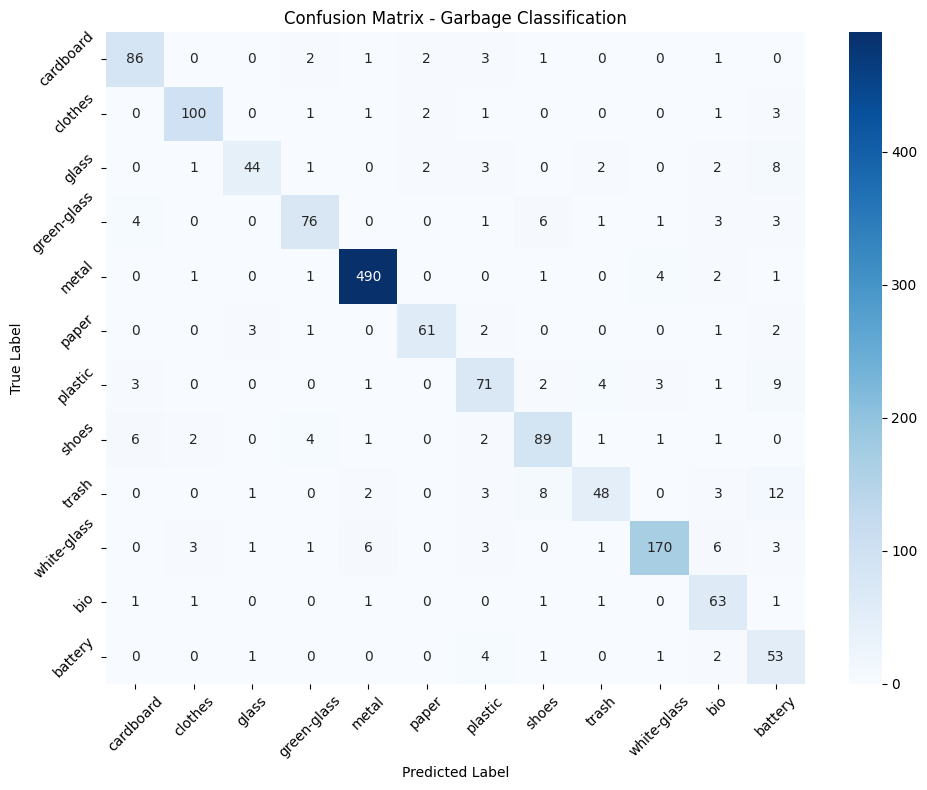

In [37]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Store true and predicted labels
y_true = []
y_pred = []

# Iterate through test dataset
for X, y in test.as_numpy_iterator():
    # Get predictions
    yhat = model.predict(X)
    
    # Append true labels (convert tensor to numpy if needed)
    y_true.extend(y)
    
    # Append predicted labels
    y_pred.extend(np.argmax(yhat, axis=1))

# ✅ Class names for 12-class garbage dataset
class_names = [
    'cardboard', 'clothes', 'glass', 'green-glass', 
    'metal', 'paper', 'plastic', 'shoes', 
    'trash', 'white-glass', 'bio', 'battery'
]

# Classification Report
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Garbage Classification")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()


In [43]:
from tensorflow.keras.metrics import SparseCategoricalAccuracy

acc = SparseCategoricalAccuracy()
for batch in test.as_numpy_iterator(): 
    X, y = batch
    yhat = model.predict(X)
    acc.update_state(y, yhat)

print("Test Accuracy:", acc.result().numpy())


1/1 [==============================] - 0s 82ms/step
Test Accuracy: 0.89127606


In [38]:
import cv2

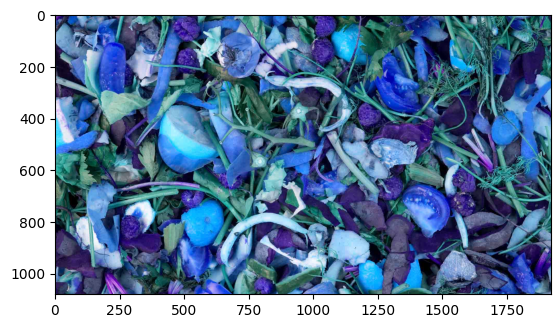

In [39]:
img = cv2.imread('154006829.jpg')
plt.imshow(img)
plt.show()

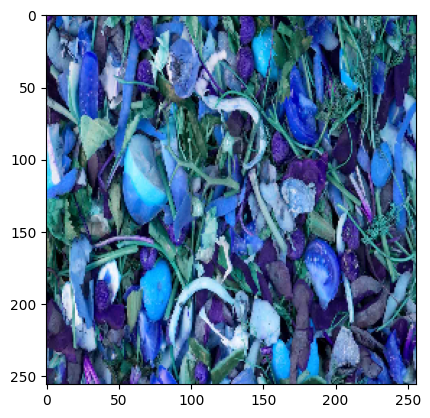

In [46]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [47]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 [==============================] - 2s 2s/step


In [48]:
yhat

array([[1.8862662e-05, 9.9819273e-01, 1.0261869e-05, 8.3556270e-06,
        7.0728805e-07, 3.0182948e-05, 1.5012760e-05, 1.4570091e-03,
        9.5038013e-06, 1.2048305e-09, 2.2693368e-04, 3.0418834e-05]],
      dtype=float32)

In [49]:
import numpy as np

# yhat is the softmax output from your model
pred_class_index = np.argmax(yhat, axis=-1)  # get the index of the highest probability

# Map index to class name
class_names = ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass','metal','paper','plastic','shoes','trash','white-glass']
pred_class_name = class_names[pred_class_index[0]]  # [0] if single sample

print(f'Predicted class is {pred_class_name}')


Predicted class is biological


In [50]:
from tensorflow.keras.models import load_model

In [51]:
model.save(os.path.join('models','imageclassifier.h5'))

In [52]:
new_model = load_model('models/imageclassifier.h5')